# SIM 1010s — Shear localization analysis

Simulations 1010–1019: hexagonal random foam compressed at 10 internal pressure levels

Pressure series: `P = [0.0] + [0.004 x sqrt(2)^i for i in 0..8]`

**Plots**
1. Shear mean (TP) vs compressive displacement from t=0 — localization point marked
2. Standard deviation of shear (element-to-element spread of the per-element shear field) vs compressive displacement from t=0 — localization point marked
3. d(Shear mean)/d(displacement) vs compressive displacement from t=0
4. d(Shear std)/d(displacement) vs compressive displacement from t=0

The shear field is `shear_e(t) = 0.5 * trace(F_e(t)^T F_e(t))` (see `docs/T2_REFERENCE.md`).
`shear_mean` is precomputed in the light `DATA_PICK_{sim}_TP2_L.pkl` files, but its
per-element standard deviation is not — it has to be recomputed from the full
per-element `shear` field in `DATA_PICK_{sim}_TP2.pkl`. Those files are ~3.2 GB each,
so the per-sim mean/std curves are computed once and cached to a small pickle
(`shear_std_cache_1010s.pkl`) next to this notebook.

In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(1010, 1020))
CACHE_PATH  = 'shear_std_cache_1010s.pkl'

In [2]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_pressure(sim):
    path = os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0

In [3]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})

{1010: '0.000000 MPa', 1011: '0.040000 MPa', 1012: '0.056569 MPa', 1013: '0.080000 MPa', 1014: '0.113137 MPa', 1015: '0.160000 MPa', 1016: '0.226274 MPa', 1017: '0.320000 MPa', 1018: '0.452548 MPa', 1019: '0.640000 MPa'}


In [4]:
from matplotlib.lines import Line2D

def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if LOC_A:
        handles.append(Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8))
        labels.append('Localization A')
    return handles, labels

## Localization point

Same convention as `SIM_1010s_analysis.ipynb`: Localization A is the displacement at
the minimum of `shear_mean`, per sim.

In [5]:
# LocalizationA = displacement at the minimum of shear_mean, per sim.
LOC_A = {}

for sim in SIMS:
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    idx_min = np.argmin(shear_mean)
    LOC_A[sim] = displ[idx_min]

LOC_A

{1010: 2.450000047683716,
 1011: 2.7649455070495605,
 1012: 2.869150161743164,
 1013: 3.0453219413757324,
 1014: 3.2962982654571533,
 1015: 3.6289710998535156,
 1016: 4.058625221252441,
 1017: 4.619215965270996,
 1018: 5.0}

## Shear mean / shear std cache

For each sim, load the full `DATA_PICK_{sim}_TP2.pkl`, rebuild the per-element x
per-frame shear array, and reduce it to `shear_mean(t)` and `shear_std(t)` (std across
elements at each frame). This mirrors `shear_mean` in the light file (sanity-checked to
match) and additionally gives the std, which the light file does not carry.

Cached to `shear_std_cache_1010s.pkl` so this expensive step only runs once.

In [6]:
def compute_shear_std_cache():
    cache = {}
    for sim in SIMS:
        path = os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2.pkl')
        if not os.path.exists(path):
            print(f'SIM {sim}: no full TP2.pkl, skipping')
            continue
        print(f'SIM {sim}: loading full TP2.pkl (~3 GB, this can take ~30s)...')
        with open(path, 'rb') as f:
            tp2 = pickle.load(f)

        t = np.array(tp2['t'])
        shear = tp2['shear']
        n_frames = len(t)
        elem_ids = list(shear.keys())

        arr = np.empty((len(elem_ids), n_frames))
        for i, eid in enumerate(elem_ids):
            d = shear[eid]
            arr[i, :] = [d[j] for j in range(n_frames)]
        del tp2, shear

        cache[sim] = {
            't': t,
            'shear_mean': arr.mean(axis=0),
            'shear_std': arr.std(axis=0),
        }
        del arr
        print(f'SIM {sim}: done')
    return cache


if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        SHEAR_CACHE = pickle.load(f)
else:
    SHEAR_CACHE = compute_shear_std_cache()
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(SHEAR_CACHE, f)

sorted(SHEAR_CACHE.keys())

SIM 1010: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1010: done
SIM 1011: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1011: done
SIM 1012: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1012: done
SIM 1013: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1013: done
SIM 1014: loading full TP2.pkl (~3 GB, this can take ~30s)...


...

SIM 1015: done
SIM 1016: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1016: done
SIM 1017: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1017: done
SIM 1018: loading full TP2.pkl (~3 GB, this can take ~30s)...


SIM 1018: done
SIM 1019: no full TP2.pkl, skipping


[1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018]

## Plot 1 — Shear mean (TP) vs compressive displacement from t=0

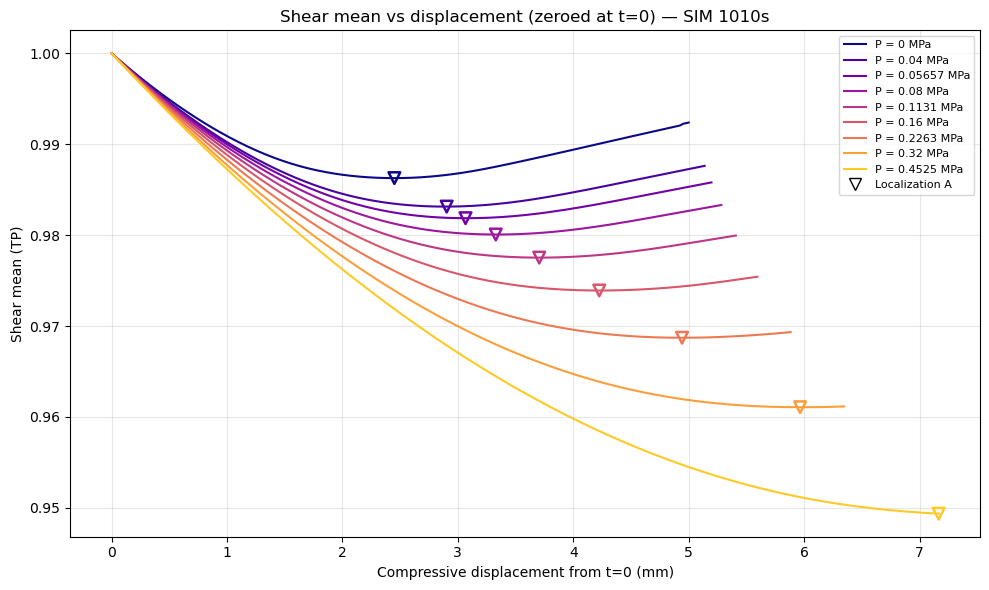

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset.
    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 2 — Standard deviation of shear (TP) vs compressive displacement from t=0

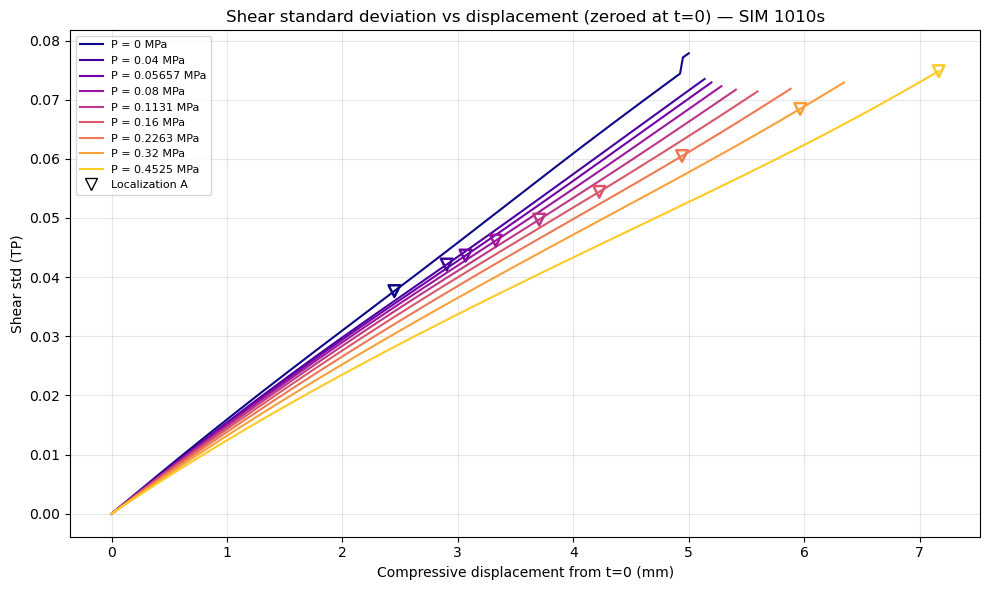

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_std, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_std)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear std (TP)')
ax.set_title('Shear standard deviation vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 3 — d(Shear mean)/d(displacement) vs compressive displacement from t=0

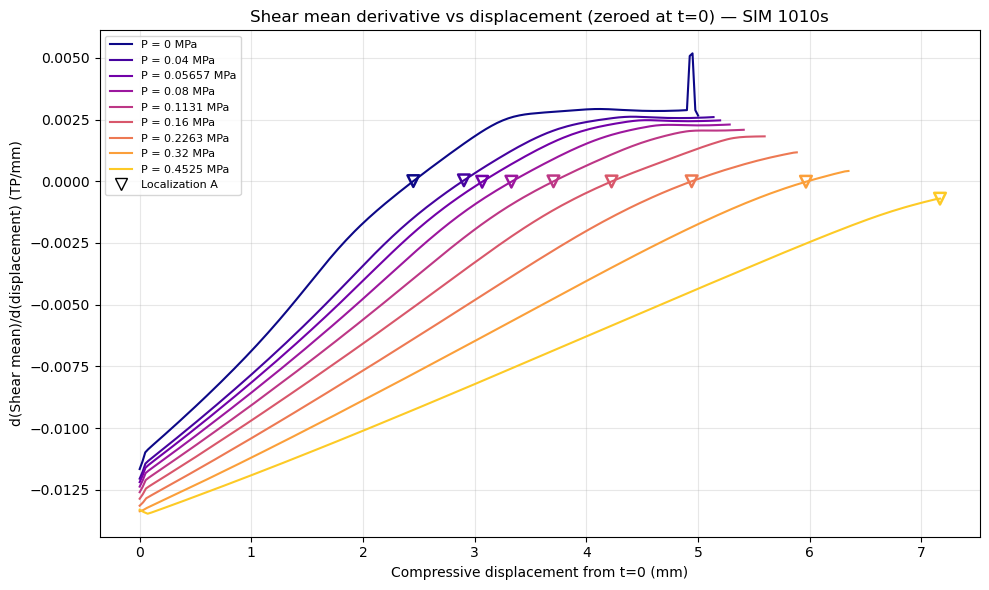

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dshear_dd  = np.gradient(shear_mean, displ_zero)

    ax.plot(displ_zero, dshear_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dshear_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 4 — d(Shear std)/d(displacement) vs compressive displacement from t=0

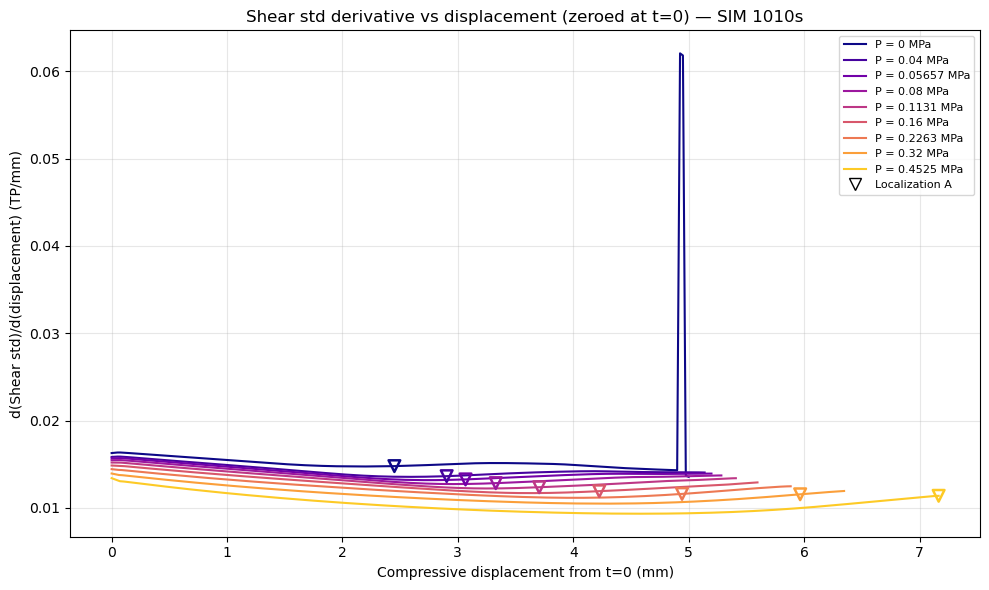

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dstd_dd    = np.gradient(shear_std, displ_zero)

    ax.plot(displ_zero, dstd_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dstd_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear std)/d(displacement) (TP/mm)')
ax.set_title('Shear std derivative vs displacement (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()